# NZ Electricity Price — Data Preparation (Steps 1–3)

Loads, cleans, resamples, merges, and feature-engineers all raw datasets into a
single hourly master DataFrame saved to `master.parquet`.

**Target:** `HAY2201` (Haywards reference node)
**Time window:** `2021-05-01 → 2024-12-31` (intersection of all sources)
**Prediction holdout:** `2024-12-25 → 2024-12-31` (last 7 days — kept for model demo)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

DATA = "../"   # source data folder — all reads here, never written
OUT  = "./"    # claude_code/ — all outputs written here

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)


## Step 1 — Load Raw Data

In [2]:
price_raw    = pd.read_csv(f"{DATA}Wholesale_price_trends_20260518210002.csv", skiprows=11)
demand_raw   = pd.read_csv(f"{DATA}Demand_trends_20260518215015.csv",          skiprows=11)
gen_raw      = pd.read_csv(f"{DATA}Generation_trends_20260519182544.csv",      skiprows=11)
hvdc_raw     = pd.read_csv(f"{DATA}HVDC_transfer_20260518215532.csv",          skiprows=10)
lake_t_raw   = pd.read_csv(f"{DATA}NI_TPO_Storage_LakeTaupo.csv")
lake_w_raw   = pd.read_csv(f"{DATA}NI_WKA_Storage_LakeWaikaremoana.csv")
wind_raw     = pd.read_csv(f"{DATA}Wind_data_100m.csv")

datasets = {
    "price": price_raw, "demand": demand_raw, "generation": gen_raw,
    "HVDC": hvdc_raw, "lake_taupo": lake_t_raw, "lake_waik": lake_w_raw,
    "wind": wind_raw,
}
for name, df in datasets.items():
    print(f"  {name:12s}  {str(df.shape):15s}  columns: {list(df.columns)[:4]}")


  price         (788832, 5)      columns: ['Period start', 'Period end', 'Region ID', 'Region']
  demand        (438240, 6)      columns: ['Period start', 'Period end', 'Region ID', 'Region']
  generation    (438240, 6)      columns: ['Period start', 'Period end', 'Region ID', 'Region']
  HVDC          (86963, 7)       columns: ['Period start', 'Period end', 'Trading period', 'Direction']
  lake_taupo    (16438, 6)       columns: ['Date', 'Time', 'Lake level (m)', 'Active storage (Mm³)']
  lake_waik     (16438, 6)       columns: ['Date', 'Time', 'Lake level (m)', 'Active storage (Mm³)']
  wind          (46704, 12)      columns: ['Unnamed: 0', 'time', 'Timaro_wind_kmh', 'Timaro_wind_direction_deg']


In [3]:
# Quick date-range check for the 30-min datasets
for name, df, col, skip in [
    ("price",      price_raw,  "Period start", True),
    ("demand",     demand_raw, "Period start", True),
    ("generation", gen_raw,    "Period start", True),
    ("HVDC",       hvdc_raw,   "Period start", True),
]:
    ts = pd.to_datetime(df[col], dayfirst=True)
    print(f"  {name:12s}  {ts.min()}  →  {ts.max()}")

wind_ts = pd.to_datetime(wind_raw["time"])
print(f"  {'wind':12s}  {wind_ts.min()}  →  {wind_ts.max()}")

for name, df in [("lake_taupo", lake_t_raw), ("lake_waik", lake_w_raw)]:
    ts = pd.to_datetime(df["Date"] + " " + df["Time"])
    ts = ts[ts >= "2021-01-01"]
    print(f"  {name:12s}  {ts.min()}  →  {ts.max()}  ({len(ts)} daily readings)")


  price         2021-05-01 00:00:00  →  2026-04-30 23:30:00


  demand        2021-01-01 00:00:00  →  2025-12-31 23:30:00


  generation    2021-05-01 00:00:00  →  2026-04-30 23:30:00
  HVDC          2021-01-01 00:00:00  →  2025-12-31 23:30:00
  wind          2021-01-01 00:00:00  →  2026-04-30 23:00:00
  lake_taupo    2021-01-01 23:59:59  →  2024-12-31 23:59:59  (1461 daily readings)
  lake_waik     2021-01-01 23:59:59  →  2024-12-31 23:59:59  (1461 daily readings)


## Step 2 — Clean & Resample to Hourly

### 2a. Wholesale Price

Pivot 8 nodes wide, resample 30-min → hourly (mean $/MWh).

In [4]:
price = price_raw.copy()
price["Period start"] = pd.to_datetime(price["Period start"], dayfirst=True)
price = (price
         .pivot(index="Period start", columns="Region ID", values="Price ($/MWh)")
         .rename_axis("datetime")
         .rename_axis(None, axis=1))
price_h = price.resample("1h").mean()
print("Price (hourly):", price_h.shape, "  nodes:", list(price_h.columns))
price_h.head(3)


Price (hourly): (43824, 9)   nodes: ['BEN2201', 'HAY2201', 'INV2201', 'ISL2201', 'KIK2201', 'OTA2201', 'RDF2201', 'SFD2201', 'WKM2201']


,BEN2201,HAY2201,INV2201,ISL2201,KIK2201,OTA2201,RDF2201,SFD2201,WKM2201
datetime,,,,,,,,,
2021-05-01 00:00:00,240.76,233.57,254.540,256.66,259.815,230.160,224.550,220.830,222.150
2021-05-01 01:00:00,255.94,248.30,272.865,272.67,278.205,241.995,234.735,233.035,233.455
2021-05-01 02:00:00,270.00,261.94,282.580,287.28,291.815,251.780,243.520,246.350,242.100


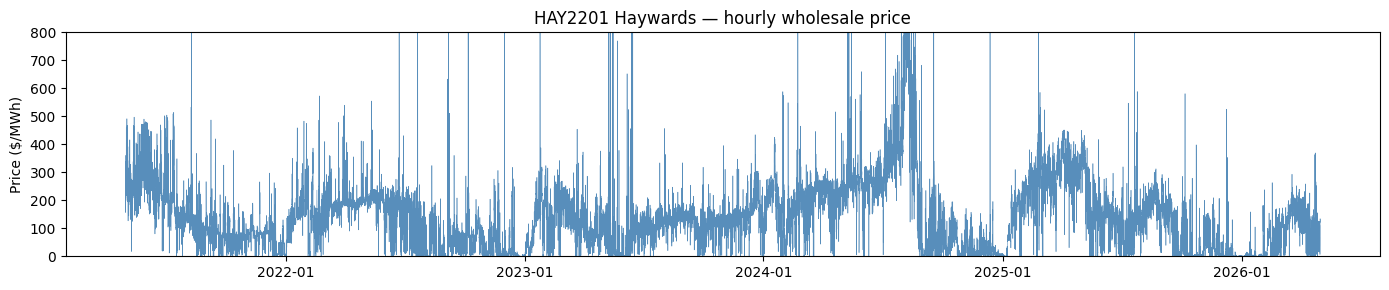

In [5]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(price_h.index, price_h["HAY2201"], lw=0.4, alpha=0.9, color="steelblue")
ax.set_ylabel("Price ($/MWh)")
ax.set_title("HAY2201 Haywards — hourly wholesale price")
ax.set_ylim(0, 800)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig(f"{OUT}fig_price_overview.png", dpi=120)
plt.show()


### 2b. Demand

Pivot 5 zones wide, resample 30-min → hourly (sum GWh).

In [6]:
demand = demand_raw.copy()
demand["Period start"] = pd.to_datetime(demand["Period start"], dayfirst=True)
demand = (demand
          .pivot(index="Period start", columns="Region ID", values="Demand (GWh)")
          .rename_axis("datetime")
          .rename_axis(None, axis=1))
demand.columns = ["demand_" + c for c in demand.columns]
demand_h = demand.resample("1h").sum()   # sum GWh across the hour
print("Demand (hourly):", demand_h.shape, list(demand_h.columns))
demand_h.head(3)


Demand (hourly): (43824, 5) ['demand_CNI', 'demand_LNI', 'demand_LSI', 'demand_UNI', 'demand_USI']


,demand_CNI,demand_LNI,demand_LSI,demand_UNI,demand_USI
datetime,,,,,
2021-01-01 00:00:00,0.680,0.424,0.916,0.932,0.478
2021-01-01 01:00:00,0.649,0.400,0.894,0.893,0.438
2021-01-01 02:00:00,0.623,0.381,0.889,0.851,0.402


### 2c. Generation

Pivot 5 zones wide, resample 30-min → hourly (sum GWh).

In [7]:
gen = gen_raw.copy()
gen["Period start"] = pd.to_datetime(gen["Period start"], dayfirst=True)
gen = (gen
       .pivot(index="Period start", columns="Region ID", values="Generation (GWh)")
       .rename_axis("datetime")
       .rename_axis(None, axis=1))
gen.columns = ["gen_" + c for c in gen.columns]
gen_h = gen.resample("1h").sum()
print("Generation (hourly):", gen_h.shape, list(gen_h.columns))
gen_h.head(3)


Generation (hourly): (43824, 5) ['gen_CNI', 'gen_LNI', 'gen_LSI', 'gen_UNI', 'gen_USI']


,gen_CNI,gen_LNI,gen_LSI,gen_UNI,gen_USI
datetime,,,,,
2021-05-01 00:00:00,1.786,0.735,1.233,0.167,0.082
2021-05-01 01:00:00,1.727,0.700,1.116,0.166,0.090
2021-05-01 02:00:00,1.720,0.549,1.133,0.167,0.094


### 2d. HVDC Transfer

Sign-encode direction: Northward = +MW, Southward = −MW. Resample to hourly (mean).

In [8]:
hvdc = hvdc_raw.copy()
hvdc["Period start"] = pd.to_datetime(hvdc["Period start"], dayfirst=True)
hvdc = hvdc.set_index("Period start").rename_axis("datetime")
hvdc["hvdc_flow_mw"] = np.where(
    hvdc["Direction"] == "Northward at Haywards",
     hvdc["Average flow (MW)"],
    -hvdc["Average flow (MW)"],
)
hvdc_h = hvdc[["hvdc_flow_mw"]].resample("1h").mean()
print("HVDC (hourly):", hvdc_h.shape)
hvdc_h.head(3)


HVDC (hourly): (43824, 1)


,hvdc_flow_mw
datetime,
2021-01-01 00:00:00,132.5
2021-01-01 01:00:00,69.5
2021-01-01 02:00:00,77.0


### 2e. Lake Storage — Daily → Hourly

Both lakes have exactly **1 reading per day** (at 23:59:59).
Linear time-interpolation creates smooth hourly values between daily measurements.


In [9]:
def lake_to_hourly(path, col_name):
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
    df = (df.sort_values("datetime")
            .set_index("datetime")
            [["Active storage (Mm³)"]]
            .rename(columns={"Active storage (Mm³)": col_name}))
    # Resample 23:59:59 daily readings → clean midnight daily index
    df_daily = df.resample("D").last()
    # Build hourly index, reindex, then linearly interpolate gaps
    hourly_idx = pd.date_range(
        df_daily.index.min(),
        df_daily.index.max() + pd.Timedelta(hours=23),
        freq="1h",
    )
    return df_daily.reindex(hourly_idx).interpolate(method="linear")

lake_t_h = lake_to_hourly(f"{DATA}NI_TPO_Storage_LakeTaupo.csv",         "lake_taupo_mm3")
lake_w_h = lake_to_hourly(f"{DATA}NI_WKA_Storage_LakeWaikaremoana.csv",  "lake_waik_mm3")

print("Lake Taupo (hourly):", lake_t_h.shape,
      lake_t_h.index.min(), "→", lake_t_h.index.max())
print("Lake Waik  (hourly):", lake_w_h.shape,
      lake_w_h.index.min(), "→", lake_w_h.index.max())
lake_t_h.head(3)


Lake Taupo (hourly): (394488, 1) 1980-01-01 00:00:00 → 2024-12-31 23:00:00
Lake Waik  (hourly): (394488, 1) 1980-01-01 00:00:00 → 2024-12-31 23:00:00


,lake_taupo_mm3
1980-01-01 00:00:00,764.6570
1980-01-01 01:00:00,764.6815
1980-01-01 02:00:00,764.7060


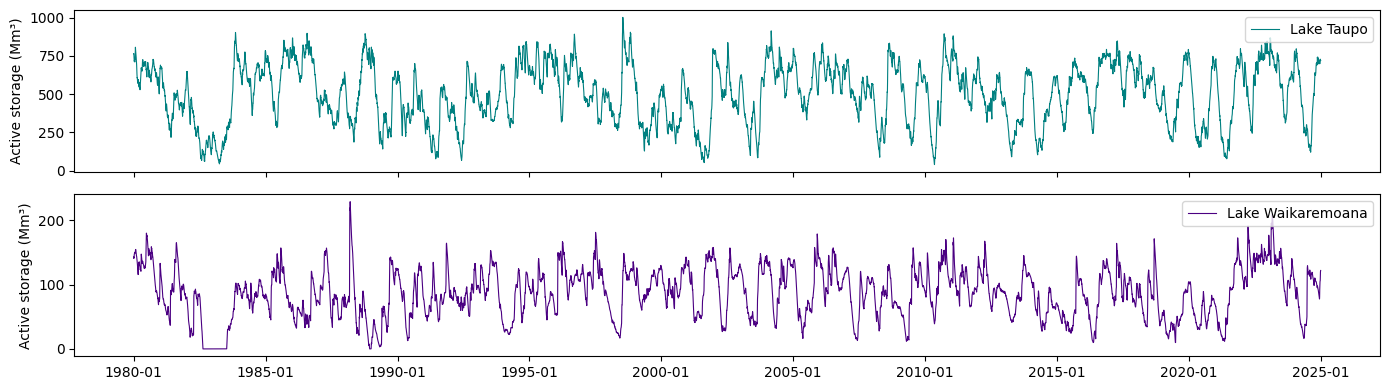

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
axes[0].plot(lake_t_h, lw=0.8, color="teal",   label="Lake Taupo")
axes[1].plot(lake_w_h, lw=0.8, color="indigo", label="Lake Waikaremoana")
for ax in axes:
    ax.set_ylabel("Active storage (Mm³)")
    ax.legend(loc="upper right")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig(f"{OUT}fig_lake_storage.png", dpi=120)
plt.show()


### 2f. Wind Data

Already hourly. Clean column names; encode wind direction as sin/cos.

In [11]:
wind = wind_raw.copy()
wind["time"] = pd.to_datetime(wind["time"])
wind = wind.set_index("time").rename_axis("datetime")
if "Unnamed: 0" in wind.columns:
    wind = wind.drop(columns=["Unnamed: 0"])

# Normalise column names → lowercase, spaces → underscores
wind.columns = (wind.columns
                .str.strip()
                .str.lower()
                .str.replace(" ", "_", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace(")", "", regex=False))

# Encode wind directions as sin/cos, drop raw degree columns
dir_cols = [c for c in wind.columns if "direction_deg" in c]
for col in dir_cols:
    prefix = col.replace("_direction_deg", "")
    rad = np.deg2rad(wind[col])
    wind[prefix + "_dir_sin"] = np.sin(rad)
    wind[prefix + "_dir_cos"] = np.cos(rad)
wind = wind.drop(columns=dir_cols)

print("Wind (hourly):", wind.shape, list(wind.columns))
wind.head(3)


Wind (hourly): (46704, 15) ['timaro_wind_kmh', 'southern_tip_wind_kmh', 'wellington_wind_kmh', 'palmerston_north_wind_kmh', 'raglan_wind_kmh', 'timaro_wind_dir_sin', 'timaro_wind_dir_cos', 'southern_tip_wind_dir_sin', 'southern_tip_wind_dir_cos', 'wellington_wind_dir_sin', 'wellington_wind_dir_cos', 'palmerston_north_wind_dir_sin', 'palmerston_north_wind_dir_cos', 'raglan_wind_dir_sin', 'raglan_wind_dir_cos']


,timaro_wind_kmh,southern_tip_wind_kmh,wellington_wind_kmh,palmerston_north_wind_kmh,raglan_wind_kmh,timaro_wind_dir_sin,timaro_wind_dir_cos,southern_tip_wind_dir_sin,southern_tip_wind_dir_cos,wellington_wind_dir_sin,wellington_wind_dir_cos,palmerston_north_wind_dir_sin,palmerston_north_wind_dir_cos,raglan_wind_dir_sin,raglan_wind_dir_cos
datetime,,,,,,,,,,,,,,,
2021-01-01 00:00:00,24.7,5.4,16.4,19.5,8.0,0.601815,0.798636,0.669131,-0.743145,0.615661,0.788011,0.961262,0.275637,-0.309017,0.951057
2021-01-01 01:00:00,22.7,4.6,17.0,16.1,8.3,0.544639,0.838671,0.629320,-0.777146,0.358368,0.933580,0.913545,0.406737,-0.034899,0.999391
2021-01-01 02:00:00,20.1,8.9,15.1,12.2,8.1,0.484810,0.874620,0.358368,-0.933580,0.017452,0.999848,0.707107,0.707107,-0.224951,0.974370


## Step 3 — Align to Common Window & Merge

| Dataset   | Start       | End         |
|-----------|-------------|-------------|
| Price     | 2021-05-01  | 2026-04-30  |
| Demand    | 2021-01-01  | 2025-12-31  |
| Generation| 2021-05-01  | 2026-04-30  |
| HVDC      | 2021-01-01  | 2025-12-31  |
| Lake      | 1980-01-01  | **2024-12-31** |
| Wind      | 2021-01-01  | 2026-04-30  |

**Intersection → 2021-05-01 to 2024-12-31** (driven by lake data end-date).


In [12]:
START = "2021-05-01 00:00:00"
END   = "2024-12-31 23:00:00"
hourly_idx = pd.date_range(START, END, freq="1h")
print(f"Common window: {START}  →  {END}  ({len(hourly_idx):,} hourly rows)")

def clip(df):
    return df.reindex(hourly_idx)

price_h  = clip(price_h)
demand_h = clip(demand_h)
gen_h    = clip(gen_h)
hvdc_h   = clip(hvdc_h)
lake_t_h = clip(lake_t_h)
lake_w_h = clip(lake_w_h)
wind_h   = clip(wind)

print("\nNaN % after alignment:")
for name, df in [("price", price_h), ("demand", demand_h), ("gen", gen_h),
                 ("hvdc", hvdc_h), ("lake_taupo", lake_t_h), ("lake_waik", lake_w_h),
                 ("wind", wind_h)]:
    pct = df.isna().mean().mean() * 100
    print(f"  {name:12s}  {pct:.3f}%")


Common window: 2021-05-01 00:00:00  →  2024-12-31 23:00:00  (32,184 hourly rows)

NaN % after alignment:
  price         0.012%
  demand        0.000%
  gen           0.000%
  hvdc          0.597%
  lake_taupo    0.000%
  lake_waik     0.000%
  wind          0.000%


In [13]:
master = pd.concat([price_h, demand_h, gen_h, hvdc_h, lake_t_h, lake_w_h, wind_h], axis=1)
print("Master after merge:", master.shape)
master.head(3)


Master after merge: (32184, 37)


,BEN2201,HAY2201,INV2201,ISL2201,KIK2201,OTA2201,RDF2201,SFD2201,WKM2201,demand_CNI,demand_LNI,demand_LSI,demand_UNI,demand_USI,gen_CNI,...,timaro_wind_kmh,southern_tip_wind_kmh,wellington_wind_kmh,palmerston_north_wind_kmh,raglan_wind_kmh,timaro_wind_dir_sin,timaro_wind_dir_cos,southern_tip_wind_dir_sin,southern_tip_wind_dir_cos,wellington_wind_dir_sin,wellington_wind_dir_cos,palmerston_north_wind_dir_sin,palmerston_north_wind_dir_cos,raglan_wind_dir_sin,raglan_wind_dir_cos
2021-05-01 00:00:00,240.76,233.57,254.540,256.66,259.815,230.160,224.550,220.830,222.150,0.829,0.472,0.961,1.043,0.581,1.786,...,35.6,11.3,42.8,25.6,32.6,-0.139173,-0.990268,-0.891007,0.453990,0.224951,-0.974370,0.292372,-0.956305,-0.731354,-0.681998
2021-05-01 01:00:00,255.94,248.30,272.865,272.67,278.205,241.995,234.735,233.035,233.455,0.803,0.441,0.934,0.981,0.530,1.727,...,32.3,12.9,40.2,29.6,31.1,-0.139173,-0.990268,-0.920505,0.390731,0.173648,-0.984808,0.453990,-0.891007,-0.743145,-0.669131
2021-05-01 02:00:00,270.00,261.94,282.580,287.28,291.815,251.780,243.520,246.350,242.100,0.780,0.420,0.923,0.945,0.493,1.720,...,30.6,16.6,44.8,24.8,29.3,-0.156434,-0.987688,-0.866025,0.500000,0.139173,-0.990268,0.469472,-0.882948,-0.707107,-0.707107


In [14]:
# Forward-fill up to 3 hours for any small gaps, then drop residual NaNs
master = master.ffill(limit=3)
remaining_nan = master.isna().sum()
print("Residual NaN per column (non-zero only):")
print(remaining_nan[remaining_nan > 0])


Residual NaN per column (non-zero only):
hvdc_flow_mw    142
dtype: int64


## Step 4 — Feature Engineering

### 4a. Cyclical Time Encodings

In [15]:
def cyc(s, period):
    return np.sin(2 * np.pi * s / period), np.cos(2 * np.pi * s / period)

idx = master.index
master["hour_sin"],  master["hour_cos"]  = cyc(idx.hour,        24)
master["dow_sin"],   master["dow_cos"]   = cyc(idx.dayofweek,    7)
master["month_sin"], master["month_cos"] = cyc(idx.month,        12)
master["is_weekend"] = (idx.dayofweek >= 5).astype(int)
print("Added cyclical time features.")


Added cyclical time features.


### 4b. Price Lags & Rolling Statistics (target: HAY2201)

In [16]:
TARGET = "HAY2201"
# Intra-day lags + full Mon-Sun weekly shape (24 h steps) + 1-week anchor
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]:
    master[f"price_lag_{lag}h"] = master[TARGET].shift(lag)

master["price_roll_mean_24h"]  = master[TARGET].shift(1).rolling(24).mean()
master["price_roll_std_24h"]   = master[TARGET].shift(1).rolling(24).std()
master["price_roll_mean_168h"] = master[TARGET].shift(1).rolling(168).mean()
print("Added price lag and rolling features.")


Added price lag and rolling features.


### 4c. Aggregate Demand / Generation Features

In [17]:
d_cols = [c for c in master.columns if c.startswith("demand_")]
g_cols = [c for c in master.columns if c.startswith("gen_")]

master["demand_total_gwh"]  = master[d_cols].sum(axis=1)
master["gen_total_gwh"]     = master[g_cols].sum(axis=1)
master["gen_demand_ratio"]  = master["gen_total_gwh"] / master["demand_total_gwh"].replace(0, np.nan)
print("Added demand/generation aggregate features.")


Added demand/generation aggregate features.


### 4d. Wind Power Proxy  (speed³, capped at 99th percentile)

In [18]:
speed_cols = [c for c in master.columns if c.endswith("_wind_kmh")]
for col in speed_cols:
    cap = master[col].quantile(0.99)
    master[col.replace("_wind_kmh", "_wind_power")] = master[col].clip(upper=cap) ** 3

power_cols = [c for c in master.columns if "_wind_power" in c]
master["wind_power_total"] = master[power_cols].sum(axis=1)
print("Wind power proxy columns:", power_cols)


Wind power proxy columns: ['timaro_wind_power', 'southern_tip_wind_power', 'wellington_wind_power', 'palmerston_north_wind_power', 'raglan_wind_power']


### 4e. NI–SI Price Spread  (HVDC congestion proxy)

In [19]:
ni_nodes = ["OTA2201", "WKM2201", "SFD2201", "HAY2201", "KIK2201"]
si_nodes = ["RDF2201", "ISL2201", "BEN2201"]
master["price_ni_mean"]       = master[ni_nodes].mean(axis=1)
master["price_si_mean"]       = master[si_nodes].mean(axis=1)
master["price_ni_si_spread"]  = master["price_ni_mean"] - master["price_si_mean"]
print("Added NI/SI spread features.")


Added NI/SI spread features.


### 4f. Lake Storage Change  (24 h delta)

In [20]:
master["lake_taupo_delta_24h"] = master["lake_taupo_mm3"].diff(24)
master["lake_waik_delta_24h"]  = master["lake_waik_mm3"].diff(24)
print("Added lake delta features.")


Added lake delta features.


## Final Check & Save

In [21]:
# Drop rows where 168h lag is still NaN (warm-up period at start)
master = master.dropna(subset=["price_lag_168h"])
print("Master shape (after warm-up drop):", master.shape)
print(f"Date range: {master.index.min()} → {master.index.max()}")
print(f"Total features: {master.shape[1]}")
print("\nColumn list:")
print(list(master.columns))


Master shape (after warm-up drop): (32016, 73)
Date range: 2021-05-08 00:00:00 → 2024-12-31 23:00:00
Total features: 73

Column list:
['BEN2201', 'HAY2201', 'INV2201', 'ISL2201', 'KIK2201', 'OTA2201', 'RDF2201', 'SFD2201', 'WKM2201', 'demand_CNI', 'demand_LNI', 'demand_LSI', 'demand_UNI', 'demand_USI', 'gen_CNI', 'gen_LNI', 'gen_LSI', 'gen_UNI', 'gen_USI', 'hvdc_flow_mw', 'lake_taupo_mm3', 'lake_waik_mm3', 'timaro_wind_kmh', 'southern_tip_wind_kmh', 'wellington_wind_kmh', 'palmerston_north_wind_kmh', 'raglan_wind_kmh', 'timaro_wind_dir_sin', 'timaro_wind_dir_cos', 'southern_tip_wind_dir_sin', 'southern_tip_wind_dir_cos', 'wellington_wind_dir_sin', 'wellington_wind_dir_cos', 'palmerston_north_wind_dir_sin', 'palmerston_north_wind_dir_cos', 'raglan_wind_dir_sin', 'raglan_wind_dir_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h', 'price_lag_48h', 'pri

In [22]:
# Check residual NaNs
nan_summary = master.isna().sum()
nan_remaining = nan_summary[nan_summary > 0]
if len(nan_remaining):
    print("Remaining NaN columns:")
    print(nan_remaining)
else:
    print("No NaN values remaining — master DataFrame is clean.")


Remaining NaN columns:
hvdc_flow_mw        142
gen_demand_ratio     23
dtype: int64


In [23]:
# Summary statistics for key columns
master[["HAY2201", "demand_total_gwh", "gen_total_gwh",
        "hvdc_flow_mw", "lake_taupo_mm3", "wind_power_total"]].describe().round(2)


,HAY2201,demand_total_gwh,gen_total_gwh,hvdc_flow_mw,lake_taupo_mm3,wind_power_total
count,32016.00,32016.00,32016.00,31874.00,32016.00,32016.00
mean,141.28,4.73,4.90,350.20,550.49,161929.10
std,132.31,0.82,0.84,227.51,205.74,143677.97
min,0.01,0.00,0.00,1.00,77.51,918.69
25%,51.62,4.06,4.19,160.50,388.64,57569.13
50%,127.30,4.82,4.99,320.00,611.94,117227.74
75%,198.42,5.28,5.47,513.00,722.27,220943.72
max,3434.28,7.30,7.59,1024.50,868.02,1014387.14


In [24]:
master.to_parquet(f"{OUT}master.parquet")
print(f"Saved → claude_code/master.parquet  ({master.shape[0]:,} rows × {master.shape[1]} cols)")


Saved → claude_code/master.parquet  (32,016 rows × 73 cols)
